# **Phising Website Detection**

**Tasks That are to be performed**

1. Imports and initialization
2. Feature Engineering/data cleaning
3. Model Training
4. Model Evaluation
5. Website generation
6. Deployment

**1.Imports & Initialization**

In [1]:
import pandas as pd
import numpy as np
import re
from urllib.parse import urlparse

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
df = pd.read_csv('phishing_site_urls.csv')

print("Dataset shape:", df.shape)
print(df.head())
print("\nLabel distribution:")
print(df['Label'].value_counts())

Dataset shape: (549346, 2)
                                                 URL Label
0  nobell.it/70ffb52d079109dca5664cce6f317373782/...   bad
1  www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...   bad
2  serviciosbys.com/paypal.cgi.bin.get-into.herf....   bad
3  mail.printakid.com/www.online.americanexpress....   bad
4  thewhiskeydregs.com/wp-content/themes/widescre...   bad

Label distribution:
Label
good    392924
bad     156422
Name: count, dtype: int64


**-> Feature engineering**

In [3]:
def extract_url_features(url):
    try:
        parsed = urlparse(url if url.startswith(('http', 'https')) else 'http://' + url)
        domain = parsed.netloc
        path = parsed.path
        query = parsed.query

        return {
            'url_length': len(url),
            'domain_length': len(domain),
            'path_length': len(path),
            'num_dots': url.count('.'),
            'num_hyphens': url.count('-'),
            'num_digits': sum(c.isdigit() for c in url),
            'num_at': url.count('@'),
            'num_eq': url.count('='),
            'num_qmark': url.count('?'),
            'num_slash': url.count('/'),
            'num_underscore': url.count('_'),
            'num_percent': url.count('%'),
            'has_ip': 1 if re.match(r'^\d+\.\d+\.\d+\.\d+$', domain.split(':')[0]) else 0,
            'num_subdomains': domain.count('.'),
            'has_https': 1 if parsed.scheme == 'https' else 0,
            'contains_login': 1 if 'login' in url.lower() else 0,
            'contains_secure': 1 if 'secure' in url.lower() else 0,
            'contains_bank': 1 if 'bank' in url.lower() else 0
        }
    except ValueError as e:
        print(f"Skipping invalid URL due to ValueError: {url} - {e}")
        return None 

extracted_data = [extract_url_features(u) for u in df['URL']]
features = pd.DataFrame([d for d in extracted_data if d is not None])
features['Label'] = df.loc[features.index, 'Label'].reset_index(drop=True)

print("Extracted feature columns:", list(features.columns))
features.head()

Skipping invalid URL due to ValueError: RybjUxÙãl5»7ÆE%ÝÔk+h|U+ýk©ìÉ½Æq]âF·õÁ¢w)ëA·ç°{t*m!¦2 - Invalid IPv6 URL
Skipping invalid URL due to ValueError: ÆeF§÷%¶¿Õ½9¿b@Ö¸ÚZE¤ÒC¢ÄÅª2åç-]W³fU¤Jgkz.ø¿nJçåæuøD%@ðûÇùM¹uË - Invalid IPv6 URL
Skipping invalid URL due to ValueError: Ó6¸RTÃu~æÙg0>÷mÖiÓ=;XZ\%êýÜÉfn&\°%7õÉ"ieÖ1ÄÁêFÐò<$cï6t[0ò2"/Æa^2âpù/ýãÇ$E¬R«È²ú[Ì¶p¥qÒ°i°^ò[»³»]±9êdÓS¿Ë]ùþ5j¿·ªocÂplà7ÊÏJ§¢#3ðDCDõ²çÇGÝ.Vò=¿QB§Ä'`ÊáZÉê ÔîÆm®ÍÝQÓ(z;¹Áê¬âytÖÙ®ëNP²ÜEQ - Invalid IPv6 URL
Skipping invalid URL due to ValueError: µÔA¨!ÝÛ=]º£¦Pôwr72-ÕY5Äòè7¬-³]×)&¡e¸¢À6RD­NvY¨Ð«Ñ3Â¸%Qñ+ÛÈ¸$¶gz{þ - Invalid IPv6 URL
Skipping invalid URL due to ValueError: ¨RÊÃûaCóÞit×ßÂe-DÖØ+9YèÌçÏ¯·"0£ÙÕ.0ößF«7¹NRÙ{ccÉÄãéçx[Ä6a5Ñ³LÖíÜÉÀ£Òma¥yRX*0ÅÝ7×ÊÁÌo«Õs¶0kdèÑ&Ä"Ï¨mZ'àDM×ñXÚÒK"päî±h¬cAÊeK@4r"^'ÓFþ1*ËË PÞô;õ$úàÑ@þ=êWÑ"Ãhñ®ç^«Ýó^çRúUJ.<6CyÜFØrÿV2ôæýZãiiIb;¨Ëµu^ÍVy)­è»âýº

,url_length,domain_length,path_length,num_dots,num_hyphens,num_digits,num_at,num_eq,num_qmark,num_slash,num_underscore,num_percent,has_ip,num_subdomains,has_https,contains_login,contains_secure,contains_bank,Label
0,225,9,125,6,4,58,0,4,1,10,4,0,0,1,0,1,0,0,bad
1,81,15,66,5,2,1,0,2,0,4,1,0,0,2,0,0,0,0,bad
2,177,16,161,7,1,47,0,0,0,11,0,0,0,1,0,0,1,0,bad
3,60,18,42,6,0,0,0,0,0,2,0,0,0,2,0,0,0,0,bad
4,116,19,60,1,1,21,0,0,1,10,0,0,0,1,0,0,0,0,bad


**-> Model Training**

In [4]:
X = features.drop('Label', axis=1)
y = features['Label']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 439466
Testing samples: 109867


In [ ]:
model = DecisionTreeClassifier(criterion='entropy', random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=42)

**-> Model Evaluation**


Classification Report:
              precision    recall  f1-score   support

         bad       0.83      0.80      0.82     31282
        good       0.92      0.94      0.93     78585

    accuracy                           0.90    109867
   macro avg       0.88      0.87      0.87    109867
weighted avg       0.90      0.90      0.90    109867

Accuracy: 0.8989232435581203


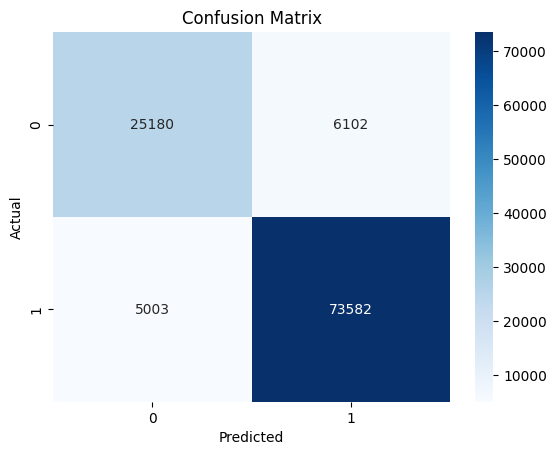

In [6]:
y_pred = model.predict(X_test)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("Accuracy:", accuracy_score(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


**-->Model Downloading**

In [7]:
import joblib
joblib.dump(model, "phishing_site_model_nb.pkl")
print("✅ Model saved as phishing_site_model_nb.pkl")


✅ Model saved as phishing_site_model_nb.pkl
